### Model Training

In [1]:
!pip install catboost

  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   - -------------------------------------- 3.4/100.2 MB 25.2 MB/s eta 0:00:04
   - -------------------------------------- 3.4/100.2 MB 25.2 MB/s eta 0:00:04
   - -------------------------------------- 5.0/100.2 MB 8.6 MB/s eta 0:00:12
   - -------------------------------------- 5.0/100.2 MB 8.6 MB/s eta 0:00:12
   -- ------------------------------------- 6.8/100.2 MB 6.7 MB/s eta 0:00:15
   -- ------------------------------------- 6.8/100.2 MB 6.7 MB/s eta 0:00:15
   --- ------------------------------------ 8.4/100.2 MB 5.6 MB/s eta 0:00:17
   --- ------------------------------------ 9.4/100.2 MB 5.6 MB/s eta 0:00:17
   ---- ----------------------------------- 10.5/100.2 MB 5.5 MB/s eta 0:00:17
   ---- ----------------------------------- 11.3/100.2 MB 5.3 MB/s eta 0:00:17
   ---- -


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   -- ------------------------------------- 2.9/48.9 MB 16.8 MB/s eta 0:00:03
   --- ------------------------------------ 3.9/48.9 MB 16.8 MB/s eta 0:00:03
   --- ------------------------------------ 4.7/48.9 MB 7.7 MB/s eta 0:00:06
   ----- ---------------------------------- 6.3/48.9 MB 7.9 MB/s eta 0:00:06
   ----- ---------------------------------- 7.1/48.9 MB 7.0 MB/s eta 0:00:06
   ------ --------------------------------- 7.6/48.9 MB 6.4 MB/s eta 0:00:07
   ------ --------------------------------- 8.4/48.9 MB 6.0 MB/s eta 0:00:07
   ------- -------------------------------- 9.4/48.9 MB 5.7 MB/s eta 0:00:07
   -------- ------------------------------- 10.2/48.9 MB 5.6 MB/s eta 0:00:07
   -------- ------------------------------- 11.0/48.9 MB 5.5 MB/s eta 0:00:07
   ---------- ----------------------------- 12.3/48.9 MB 5.4 MB/s eta 0:00:07
   ---------- ----------------------------- 13.1/48.9 MB 5.4 MB/s eta 0:00:07



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [7]:
df = pd.read_csv('data/stud.csv')

In [8]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
X = df.drop(columns=['math_score'])

In [10]:
y = df['math_score']

In [11]:
num_features = X.select_dtypes(exclude="str").columns
cat_features = X.select_dtypes(include="str").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)


In [12]:
X = preprocessor.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
print(X_train.shape)
print(X_test.shape)

(800, 19)
(200, 19)


In [23]:
def evaluation_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "CatBoosting Regressor" : CatBoostRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae , model_train_rmse , model_train_r2 = evaluation_model(y_train, y_train_pred)
    model_test_mae , model_test_rmse, model_test_r2 = evaluation_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance for Training Set")
    print("-Root Mean Sqaured Error: {:.4f}".format(model_train_rmse))
    print("-Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print("-----------------------------------------------------------")
    print("Model performance for Test Set")
    print("-Root Mean Sqaured Error: {:.4f}".format(model_test_rmse))
    print("-Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print("="*35)
    print("\n")




Linear Regression
Model Performance for Training Set
-Root Mean Sqaured Error: 5.3231
-Mean Absolute Error: 4.2667
- R2 Score: 0.8743
-----------------------------------------------------------
Model performance for Test Set
-Root Mean Sqaured Error: 5.3940
-Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model Performance for Training Set
-Root Mean Sqaured Error: 6.5938
-Mean Absolute Error: 5.2063
- R2 Score: 0.8071
-----------------------------------------------------------
Model performance for Test Set
-Root Mean Sqaured Error: 6.5197
-Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model Performance for Training Set
-Root Mean Sqaured Error: 5.3233
-Mean Absolute Error: 4.2650
- R2 Score: 0.8743
-----------------------------------------------------------
Model performance for Test Set
-Root Mean Sqaured Error: 5.3904
-Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model Performance for Training Set
-Root Mean Sqaured Error: 5.7077
-Mean Abso

In [29]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']). sort_values(by=["R2_Score"], ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.853836
6,CatBoosting Regressor,0.851632
7,AdaBoost Regressor,0.849004
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree Regressor,0.746937


In [30]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_test_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 84.90


Text(0, 0.5, 'Preducted')

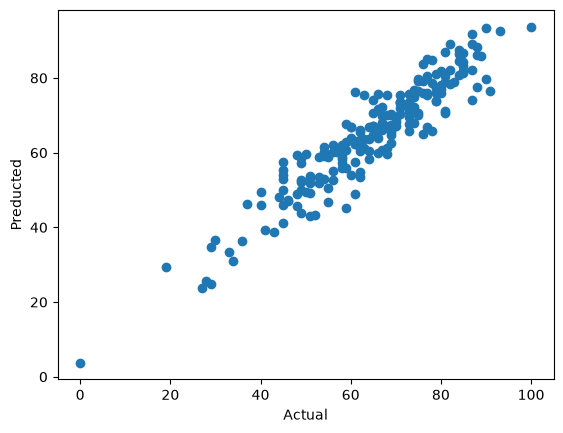

In [31]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Preducted")

<Axes: xlabel='math_score'>

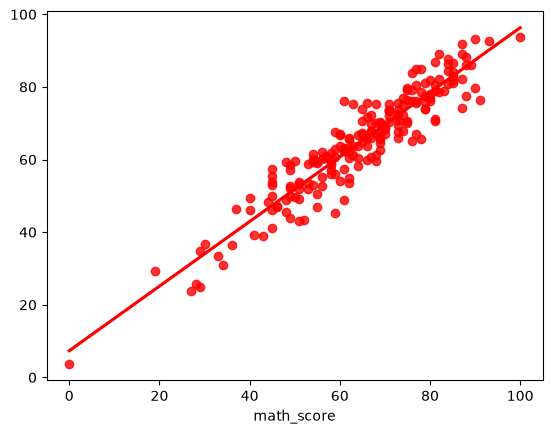

In [32]:
sns.regplot(x=y_test, y=y_pred, ci=None, color="red")

In [33]:
pred_df = pd.DataFrame({'Actual Value' :y_test, 'Predicted Value':y_pred, 'Difference' : y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
